# 07 발표용 관점별 해석 표

`modeling_dataset.csv`를 사용해 최신 월 기준 관점별 위험 신호 표를 생성한다.

이 노트북은 가격 예측 모델의 핵심 결과가 아니라, 예측 결과를 실거주자·투자자·정체 구간 관점으로 해석하기 위한 보조 자료를 만든다.

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "modeling_dataset.csv"
TABLE_DIR = ROOT / "outputs" / "presentation_tables"
FIG_DIR = ROOT / "outputs" / "figures" / "presentation"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("입력 파일:", DATA_PATH)
print("표 저장:", TABLE_DIR)
print("그림 저장:", FIG_DIR)

입력 파일: /Users/min/RealEstate-Risk-Radar/data/processed/modeling_dataset.csv
표 저장: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables
그림 저장: /Users/min/RealEstate-Risk-Radar/outputs/figures/presentation


In [16]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

df["contract_month"] = pd.to_datetime(df["contract_month"])
latest_month = df["contract_month"].max()
latest_df = df[df["contract_month"] == latest_month].copy()

print("데이터 크기:", df.shape)
print("최신 월:", latest_month.strftime("%Y-%m"))
print("최신 월 데이터:", latest_df.shape)

데이터 크기: (850, 59)
최신 월: 2026-03
최신 월 데이터: (25, 59)


In [17]:
presentation_table = latest_df[[
    "gu",
    "resident_risk_index",
    "investor_risk_index",
    "stagnation_score",
    "total_risk_score",
    "risk_grade"
]].copy()

presentation_table = presentation_table.rename(columns={
    "gu": "자치구",
    "resident_risk_index": "실거주자 위험 점수",
    "investor_risk_index": "투자자 위험 점수",
    "stagnation_score": "정체도 점수",
    "total_risk_score": "종합 위험 점수",
    "risk_grade": "위험 등급"
})

score_cols = ["실거주자 위험 점수", "투자자 위험 점수", "정체도 점수", "종합 위험 점수"]

for col in score_cols:
    presentation_table[col] = presentation_table[col].round(3)

presentation_top10 = (
    presentation_table
    .sort_values("종합 위험 점수", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

presentation_top10.insert(0, "순위", range(1, len(presentation_top10) + 1))

presentation_top10.to_csv(
    TABLE_DIR / "latest_presentation_risk_table.csv",
    index=False,
    encoding="utf-8-sig"
)

presentation_top10

,순위,자치구,실거주자 위험 점수,투자자 위험 점수,정체도 점수,종합 위험 점수,위험 등급
0,1,용산구,0.627,0.512,0.80,0.570,높음
1,2,강남구,0.600,0.470,0.20,0.535,높음
2,3,송파구,0.586,0.478,0.45,0.532,높음
3,4,강서구,0.550,0.482,0.45,0.516,높음
4,5,강동구,0.528,0.452,0.60,0.490,주의
5,6,동작구,0.517,0.446,0.45,0.482,주의
6,7,중랑구,0.527,0.424,0.40,0.476,주의
7,8,마포구,0.525,0.415,0.55,0.470,주의
8,9,영등포구,0.503,0.413,0.45,0.458,주의
9,10,성동구,0.492,0.407,0.65,0.449,주의


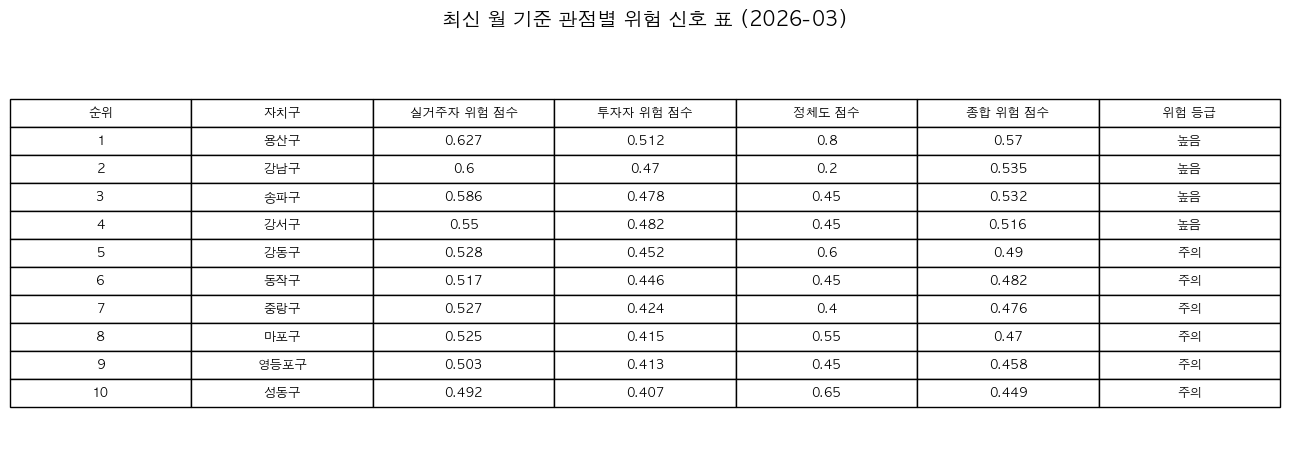

In [18]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.axis("off")

table = ax.table(
    cellText=presentation_top10.values,
    colLabels=presentation_top10.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

ax.set_title(
    f"최신 월 기준 관점별 위험 신호 표 ({latest_month.strftime('%Y-%m')})",
    fontsize=14,
    pad=14
)

plt.tight_layout()
plt.savefig(FIG_DIR / "latest_presentation_risk_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
top10_info = {
    "resident_risk_top10.csv": "실거주자 위험 점수",
    "investor_risk_top10.csv": "투자자 위험 점수",
    "stagnation_score_top10.csv": "정체도 점수",
}

for filename, score_col in top10_info.items():
    top10 = (
        presentation_table[["자치구", score_col]]
        .sort_values(score_col, ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    top10.insert(0, "순위", range(1, len(top10) + 1))
    top10.to_csv(TABLE_DIR / filename, index=False, encoding="utf-8-sig")

    print(filename)
    display(top10)

resident_risk_top10.csv


,순위,자치구,실거주자 위험 점수
0,1,용산구,0.627
1,2,강남구,0.600
2,3,송파구,0.586
3,4,강서구,0.550
4,5,강동구,0.528
5,6,중랑구,0.527
6,7,마포구,0.525
7,8,동작구,0.517
8,9,영등포구,0.503
9,10,성동구,0.492


investor_risk_top10.csv


,순위,자치구,투자자 위험 점수
0,1,용산구,0.512
1,2,강서구,0.482
2,3,송파구,0.478
3,4,강남구,0.470
4,5,강동구,0.452
5,6,동작구,0.446
6,7,중랑구,0.424
7,8,마포구,0.415
8,9,영등포구,0.413
9,10,성동구,0.407


stagnation_score_top10.csv


,순위,자치구,정체도 점수
0,1,용산구,0.80
1,2,성동구,0.65
2,3,강동구,0.60
3,4,마포구,0.55
4,5,강북구,0.50
5,6,관악구,0.50
6,7,강서구,0.45
7,8,영등포구,0.45
8,9,송파구,0.45
9,10,노원구,0.45


In [20]:
print("생성된 발표용 표 파일")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(path.name)

print("\n생성된 발표용 이미지")
for path in sorted(FIG_DIR.glob("*.png")):
    print(path.name)

생성된 발표용 표 파일
investor_risk_top10.csv
latest_presentation_risk_table.csv
resident_risk_top10.csv
stagnation_score_top10.csv

생성된 발표용 이미지
latest_presentation_risk_table.png


In [21]:

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

데이터 크기: (850, 59)
컬럼 목록:
['sggCd', 'gu', 'contract_month', 'avg_sale_price', 'med_sale_price', 'avg_sale_price_per_m2', 'med_sale_price_per_m2', 'sale_count', 'avg_jeonse_deposit', 'med_jeonse_deposit', 'avg_jeonse_deposit_per_m2', 'med_jeonse_deposit_per_m2', 'jeonse_count', 'total_rent_count', 'monthly_count', 'monthly_ratio', 'jeonse_rate', 'gap_rate', 'sale_growth_1m', 'jeonse_growth_1m', 'growth_gap_1m', 'sale_volume_growth_1m', 'rent_volume_growth_1m', 'next_month_sale_price', 'price_gap', 'purchase_burden_gap', 'gap_direction', 'sale_over_jeonse_gap_ratio', 'jeonse_over_sale_gap_ratio', 'gap_abs_ratio', 'monthly_ratio_diff', 'monthly_ratio_pct_change', 'monthly_shift_abs', 'sale_growth_acceleration', 'sale_growth_vs_market', 'low_jeonse_rate_score', 'gap_rate_score', 'sale_growth_score', 'growth_gap_score', 'sale_volume_change_score', 'rent_volume_change_score', 'monthly_ratio_score', 'monthly_shift_score', 'jeonse_weakness_score', 'resident_risk_index', 'investor_risk_index', '

In [22]:

def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

gu_col = pick_col(["gu", "region", "자치구"], df.columns)
month_col = pick_col(["contract_month", "계약월"], df.columns)

resident_col = pick_col(
    ["resident_risk_index", "resident_risk_score", "user_risk_score"],
    df.columns
)

investor_col = pick_col(
    ["investor_risk_index", "investor_risk_score"],
    df.columns
)

stagnation_col = pick_col(
    ["stagnation_score", "stagnation_risk_score", "stagnation_index"],
    df.columns
)

print("자치구 컬럼:", gu_col)
print("월 컬럼:", month_col)
print("실거주자 위험 점수 컬럼:", resident_col)
print("투자자 위험 점수 컬럼:", investor_col)
print("정체도 점수 컬럼:", stagnation_col)

required_cols = [gu_col, month_col, resident_col, investor_col, stagnation_col]
if any(c is None for c in required_cols):
    raise ValueError("필수 컬럼을 찾지 못했습니다. 위 출력 결과를 확인하세요.")

자치구 컬럼: gu
월 컬럼: contract_month
실거주자 위험 점수 컬럼: resident_risk_index
투자자 위험 점수 컬럼: investor_risk_index
정체도 점수 컬럼: stagnation_score


In [23]:

def convert_contract_month(series):
    s = series.copy()


    if pd.api.types.is_numeric_dtype(s):
        s = s.astype("Int64").astype(str)
    else:
        s = s.astype(str).str.strip()

    s = s.str.replace("/", "-", regex=False)

    parsed = pd.to_datetime(s, format="%Y%m", errors="coerce")
    parsed2 = pd.to_datetime(s, errors="coerce")

    return parsed.fillna(parsed2)

df[month_col] = convert_contract_month(df[month_col])

if df[month_col].isna().all():
    raise ValueError("contract_month 변환에 실패했습니다. 원본 값을 확인하세요.")

latest_month = df[month_col].max()
latest_df = df[df[month_col] == latest_month].copy()

print("최신 월:", latest_month.strftime("%Y-%m"))
print("최신 월 데이터 크기:", latest_df.shape)

최신 월: 2026-03
최신 월 데이터 크기: (25, 59)


In [24]:

def make_top10_chart(data, score_col, title, png_filename, csv_filename):
    top10 = (
        data[[gu_col, score_col]]
        .dropna()
        .sort_values(score_col, ascending=False)
        .head(10)
        .copy()
    )

    top10[score_col] = top10[score_col].round(3)

    # CSV 저장
    csv_path = TABLE_DIR / csv_filename
    top10.to_csv(csv_path, index=False, encoding="utf-8-sig")


    plot_df = top10.sort_values(score_col, ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df[gu_col], plot_df[score_col])
    plt.xlabel("점수")
    plt.ylabel("자치구")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)

    for i, value in enumerate(plot_df[score_col]):
        plt.text(value + 0.005, i, f"{value:.3f}", va="center", fontsize=9)

    plt.tight_layout()

    png_path = FIG_DIR / png_filename
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"CSV 저장 완료: {csv_path}")
    print(f"PNG 저장 완료: {png_path}")

    return top10

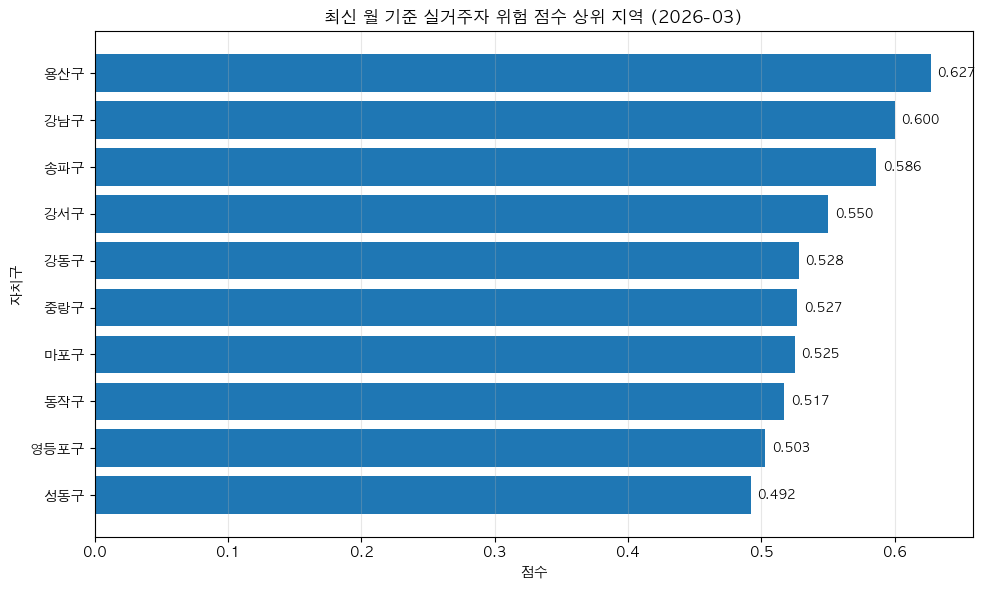

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/resident_risk_top10.csv
PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/presentation/resident_risk_top10.png


,gu,resident_risk_index
713,용산구,0.627
33,강남구,0.600
611,송파구,0.586
135,강서구,0.550
67,강동구,0.528
849,중랑구,0.527
441,마포구,0.525
407,동작구,0.517
679,영등포구,0.503
543,성동구,0.492


In [25]:

# 실거주자 위험 점수 Top 10

resident_top10 = make_top10_chart(
    latest_df,
    resident_col,
    f"최신 월 기준 실거주자 위험 점수 상위 지역 ({latest_month.strftime('%Y-%m')})",
    "resident_risk_top10.png",
    "resident_risk_top10.csv"
)

resident_top10

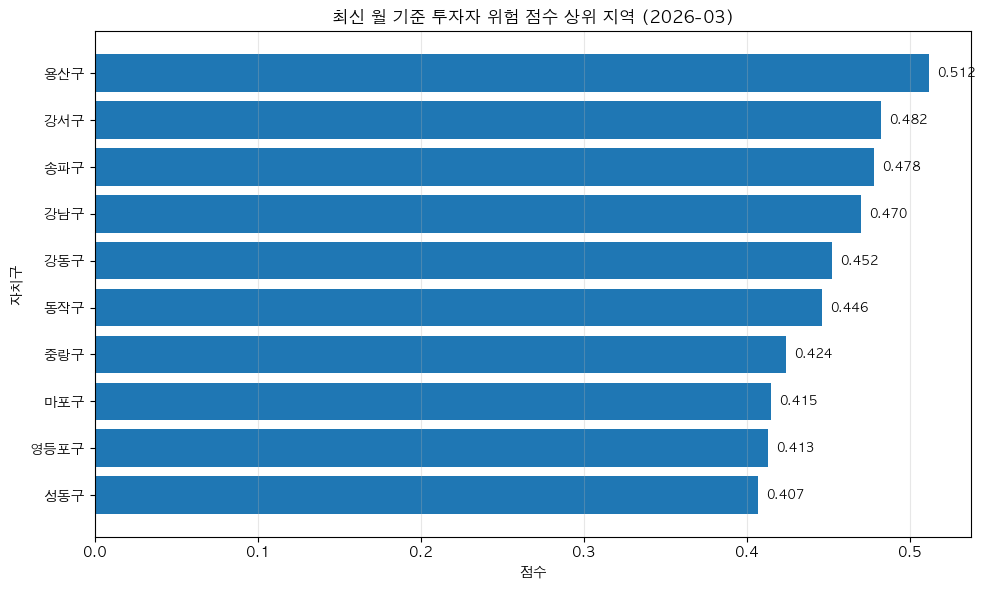

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/investor_risk_top10.csv
PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/presentation/investor_risk_top10.png


,gu,investor_risk_index
713,용산구,0.512
135,강서구,0.482
611,송파구,0.478
33,강남구,0.470
67,강동구,0.452
407,동작구,0.446
849,중랑구,0.424
441,마포구,0.415
679,영등포구,0.413
543,성동구,0.407


In [26]:

# 투자자 위험 점수 Top 10

investor_top10 = make_top10_chart(
    latest_df,
    investor_col,
    f"최신 월 기준 투자자 위험 점수 상위 지역 ({latest_month.strftime('%Y-%m')})",
    "investor_risk_top10.png",
    "investor_risk_top10.csv"
)

investor_top10

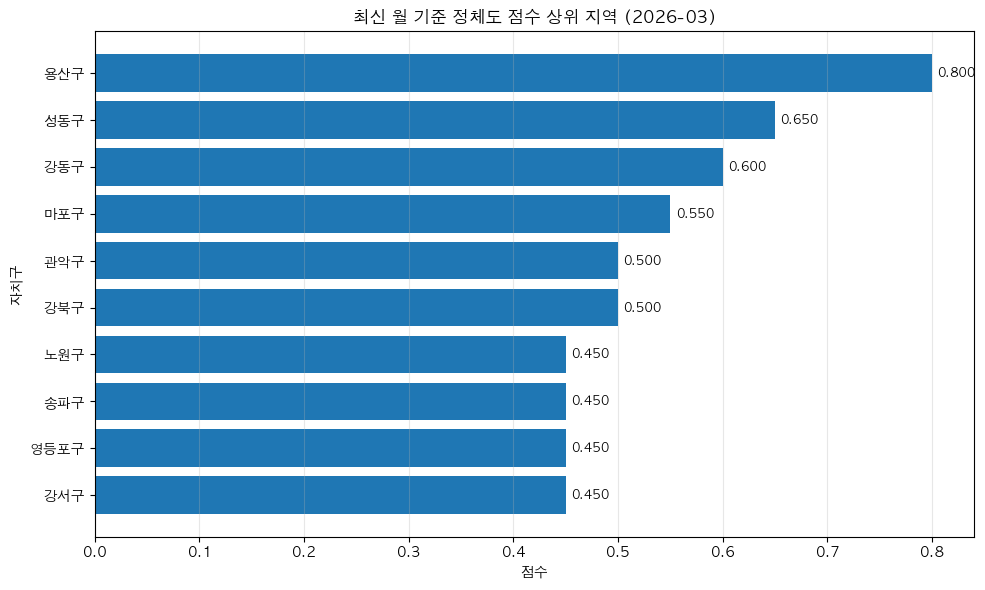

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/stagnation_score_top10.csv
PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/presentation/stagnation_score_top10.png


,gu,stagnation_score
713,용산구,0.80
543,성동구,0.65
67,강동구,0.60
441,마포구,0.55
101,강북구,0.50
169,관악구,0.50
135,강서구,0.45
679,영등포구,0.45
611,송파구,0.45
305,노원구,0.45


In [27]:

# 정체도 점수 Top 10

stagnation_top10 = make_top10_chart(
    latest_df,
    stagnation_col,
    f"최신 월 기준 정체도 점수 상위 지역 ({latest_month.strftime('%Y-%m')})",
    "stagnation_score_top10.png",
    "stagnation_score_top10.csv"
)

stagnation_top10

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

사용 파일: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/latest_presentation_risk_table.csv
저장 파일: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/latest_presentation_risk_table_heatmap.png


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

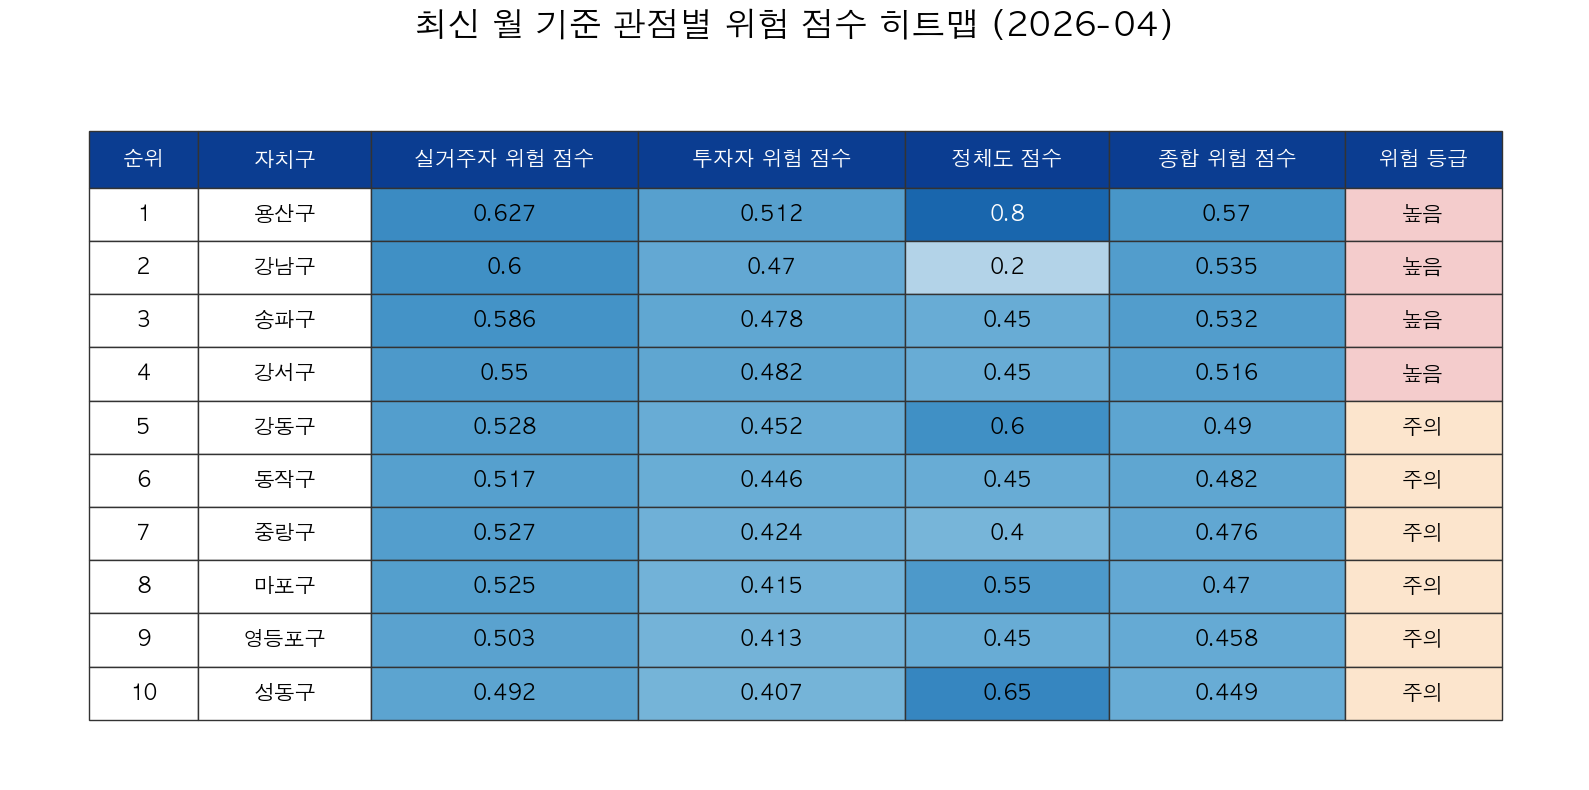

표형 히트맵 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/latest_presentation_risk_table_heatmap.png


In [28]:
# 22번 슬라이드용: 관점별 위험 점수 표형 히트맵 생성
# latest_presentation_risk_table.csv를 이용해 숫자는 유지하고,
# 점수 열만 색으로 강조한 표 이미지를 만든다.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# =========================
# 1. 경로 설정
# =========================
ROOT = Path.cwd()

# notebooks 폴더에서 실행 중이면 프로젝트 루트로 이동
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PRESENTATION_DIR = ROOT / "outputs" / "presentation_tables"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

input_path = PRESENTATION_DIR / "latest_presentation_risk_table.csv"
output_path = PRESENTATION_DIR / "latest_presentation_risk_table_heatmap.png"

print("사용 파일:", input_path)
print("저장 파일:", output_path)

# =========================
# 2. 데이터 불러오기
# =========================
df = pd.read_csv(input_path, encoding="utf-8-sig")

# 혹시 순위가 문자열로 읽혀도 정렬되도록 처리
df = df.sort_values("순위").reset_index(drop=True)

# 점수 표시 자리수 정리
score_cols = ["실거주자 위험 점수", "투자자 위험 점수", "정체도 점수", "종합 위험 점수"]

display_df = df.copy()

for col in score_cols:
    display_df[col] = display_df[col].astype(float).round(3)

# =========================
# 3. 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 4. 셀 색상 만들기
# =========================
# 점수는 0~1 기준으로 색을 부여한다.
# 값이 높을수록 더 진한 파란색으로 표시된다.
cmap = mpl.cm.Blues

cell_text = display_df.astype(str).values.tolist()
col_labels = display_df.columns.tolist()

cell_colors = []

for i in range(len(display_df)):
    row_colors = []
    
    for col in col_labels:
        if col in score_cols:
            value = float(display_df.loc[i, col])
            
            # 너무 연하게 보이지 않도록 0.15~0.95 범위로 조정
            color_strength = 0.15 + (value * 0.80)
            row_colors.append(cmap(color_strength))
        
        elif col == "위험 등급":
            grade = display_df.loc[i, col]
            
            if grade == "높음":
                row_colors.append("#F4CCCC")   # 연한 빨강
            elif grade == "주의":
                row_colors.append("#FCE5CD")   # 연한 주황
            elif grade == "보통":
                row_colors.append("#FFF2CC")   # 연한 노랑
            elif grade == "안정":
                row_colors.append("#D9EAD3")   # 연한 초록
            elif grade == "낮음":
                row_colors.append("#D9EAF7")   # 연한 파랑
            else:
                row_colors.append("#FFFFFF")
        
        else:
            row_colors.append("#FFFFFF")
    
    cell_colors.append(row_colors)

# 헤더 색
header_colors = ["#0B3D91"] * len(col_labels)

# =========================
# 5. 표형 히트맵 그리기
# =========================
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    colColours=header_colors,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# 글자 크기와 셀 크기 조정
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 2.0)

# 열 너비 조정
col_widths = {
    0: 0.07,  # 순위
    1: 0.11,  # 자치구
    2: 0.17,  # 실거주자 위험 점수
    3: 0.17,  # 투자자 위험 점수
    4: 0.13,  # 정체도 점수
    5: 0.15,  # 종합 위험 점수
    6: 0.10,  # 위험 등급
}

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#333333")
    cell.set_linewidth(1.0)
    
    if col in col_widths:
        cell.set_width(col_widths[col])
    
    # 헤더 스타일
    if row == 0:
        cell.set_text_props(color="white", weight="bold")
        cell.set_height(0.08)
    else:
        cell.set_height(0.075)
        
        # 점수가 높은 파란 셀은 글자 흰색으로
        if col_labels[col] in score_cols:
            value = float(display_df.iloc[row - 1, col])
            if value >= 0.75:
                cell.set_text_props(color="white", weight="bold")
            else:
                cell.set_text_props(color="black")
        
        # 순위, 자치구는 굵게
        if col_labels[col] in ["순위", "자치구"]:
            cell.set_text_props(weight="bold")

plt.title(
    "최신 월 기준 관점별 위험 점수 히트맵 (2026-04)",
    fontsize=24,
    weight="bold",
    pad=25
)

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("표형 히트맵 저장 완료:", output_path)